# Week 5 — The Real ML Workflow: Train/Test Splits, Regression, Classification, KNN

**Course context:** Weeks 3-4 built models and evaluated them on the *same* data they were trained on — which tells you how well a model memorizes, not how well it generalizes. This week fixes that with the train/test split, then covers the two fundamental ML task types: regression (predicting a number) and classification (predicting a category).

**Data file needed:** Day 7 uses `Telco-Customer-Churn.csv`, included alongside this notebook — keep it in the same folder.

**How this notebook is organized:** one section per day, each with: what it covers → why it matters for AI work → code → pitfalls.


## Day 1 — Train/Test Split: Why You Can't Evaluate a Model on Its Own Training Data

**What it covers:** Splitting a dataset into a training set (model learns from this) and a test set (model is evaluated on this, having never seen it).

**Why it matters for AI work:** This is arguably the single most important habit in applied ML. A model can achieve near-perfect performance on data it memorized during training while being useless on new data (this is called **overfitting**). The test set is your only honest signal of real-world performance. Skip this and every metric you report is potentially misleading.

**When to use what:**
- `test_size=0.2` (80/20 split) — common default. More test data = more reliable evaluation, but less data to train on. Smaller datasets sometimes use 70/30 or cross-validation (Day 5) instead of a single split.
- `random_state=42` — fixes *which* rows end up in train vs test, so your split (and results) are reproducible across runs.

**Pitfalls:**
- Never look at test set performance repeatedly while tuning a model and adjusting based on it — that slowly turns your "test" set into a second training set by proxy (you're indirectly fitting to it). For heavy tuning, use a separate validation set or cross-validation, and touch the test set only once, at the end.
- Splitting *before* any preprocessing that "looks at the whole dataset" (like scaling using the full dataset's mean/std) leaks information from the test set into training. Always fit preprocessing steps (scalers, encoders) on the training set only, then apply them to the test set — Day 6 shows this pattern.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

features = df[["total_bill", "size"]]
target = df["tip"]

print("Features:\n", features.head())
print("Target:\n", target.head())

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Features:
    total_bill  size
0       16.99     2
1       10.34     3
2       21.01     3
3       23.68     2
4       24.59     4
Target:
 0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64

Training set shape: (195, 2)
Testing set shape: (49, 2)


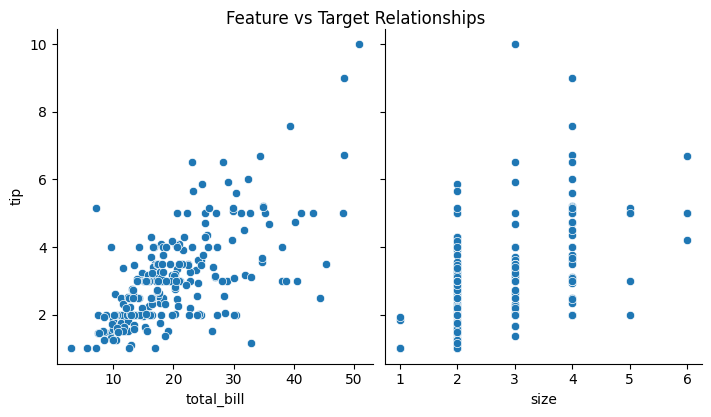

In [2]:
sns.pairplot(df, x_vars=["total_bill", "size"], y_vars="tip", height=4, aspect=0.9, kind="scatter")
plt.suptitle("Feature vs Target Relationships", y=1.02)
plt.show()

## Day 2 — Regression Done Properly: Train, Predict, Evaluate on Unseen Data

**What it covers:** The full, correct regression workflow — split, fit on train only, predict on test, evaluate with metrics computed only on test predictions.

**Why it matters for AI work:** This is the template you'll reuse for every regression problem in this course and beyond. The pattern (`train_test_split` → `fit` → `predict` → `mean_squared_error`/`r2_score`) doesn't change; only the model class does.

**Reading the metrics correctly:**
- Compare train MSE/R² vs test MSE/R² if you want to detect overfitting — a model that's much better on train than test is overfitting.
- A test R² close to the train R² (both reasonably high) means the model generalizes well.

**Pitfalls:**
- Comparing predictions visually (scatter plot) is worth doing alongside the numeric metrics — a metric alone can hide *where* the model is wrong (e.g. consistently underpredicting large values).


Slope:  2.99197294629921  (true value: 3)
Intercept:  0.28582663891720017  (true value: ~0)


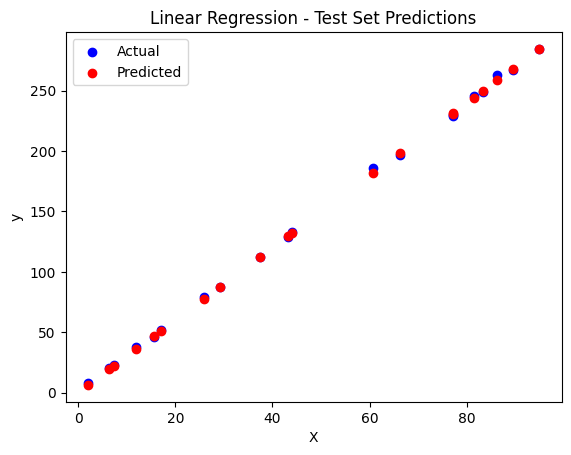

Test MSE:  2.6147980548679617
Test R-Squared:  0.9997030960054532


In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
X = np.random.rand(100, 1) * 100
y = 3 * X + np.random.randn(100, 1) * 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)   # fit ONLY on training data

y_pred = model.predict(X_test)   # predict on data the model has never seen

print("Slope: ", model.coef_[0][0], " (true value: 3)")
print("Intercept: ", model.intercept_[0], " (true value: ~0)")

plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.scatter(X_test, y_pred, color="red", label="Predicted")
plt.title("Linear Regression - Test Set Predictions")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Test MSE: ", mse)
print("Test R-Squared: ", r2)

## Day 3 — Polynomial Regression and Regularization (Ridge, Lasso)

**What it covers:** Fitting curves (not just straight lines) with polynomial features, and controlling overfitting with regularization (Ridge = L2 penalty, Lasso = L1 penalty).

**Why it matters for AI work:** Real relationships are rarely perfectly linear. Polynomial features let a linear model fit curves. But more flexible models overfit more easily — regularization is the standard fix, and Ridge/Lasso are the simplest, most interpretable versions of a technique (penalizing large weights) that shows up again in every neural network you'll train (as "weight decay").

**When to use what:**
- **Polynomial features** — when a scatter plot shows a clear curve, not a line (check visually first, Week 2 Day 6 style)
- **Ridge (L2)** — shrinks all coefficients toward zero, keeps all features, good default when you believe most features are somewhat useful
- **Lasso (L1)** — can shrink coefficients all the way to **exactly zero**, effectively doing feature selection automatically. Useful when you suspect many features are irrelevant.
- `alpha` — the regularization strength. Higher `alpha` = stronger penalty = simpler model (risk of underfitting). Lower `alpha` = closer to plain linear regression (risk of overfitting). This is a hyperparameter you'll tune properly in Week 8.

**Pitfalls:**
- Increasing polynomial degree without regularization is a classic overfitting trap — the curve starts wiggling to hit every training point exactly, and generalizes terribly. Higher degree needs regularization to stay controlled.
- Ridge and Lasso are sensitive to feature scale — features on very different scales (e.g. income in dollars vs age in years) get penalized unevenly. Scale your features first (Day 6 shows `StandardScaler`) when using regularization on multi-feature data.


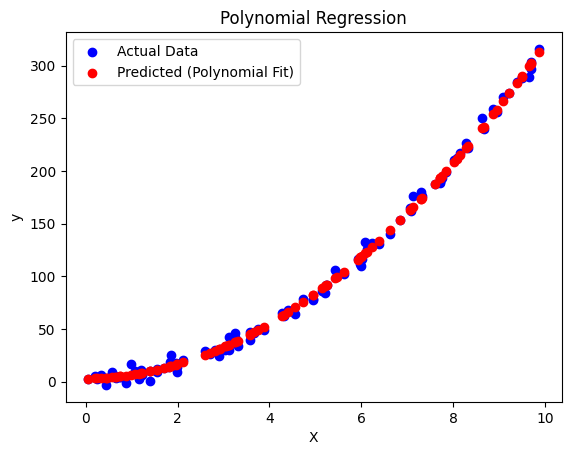

MSE: 19.4298416587559


In [4]:
from sklearn.preprocessing import PolynomialFeatures

# Data with a genuine curve (quadratic relationship), not a straight line
np.random.seed(42)
X_curve = np.random.rand(100, 1) * 10
y_curve = 3 * X_curve**2 + 2 * X_curve + np.random.randn(100, 1) * 5

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X_curve)   # adds an X^2 column alongside X

model = LinearRegression()
model.fit(X_poly, y_curve)
y_pred_curve = model.predict(X_poly)

plt.scatter(X_curve, y_curve, color="blue", label="Actual Data")
plt.scatter(X_curve, y_pred_curve, color="red", label="Predicted (Polynomial Fit)")
plt.title("Polynomial Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

print("MSE:", mean_squared_error(y_curve, y_pred_curve))

Ridge Regression MSE: 0.36342010999336966
Lasso Regression MSE: 0.34484245324815377


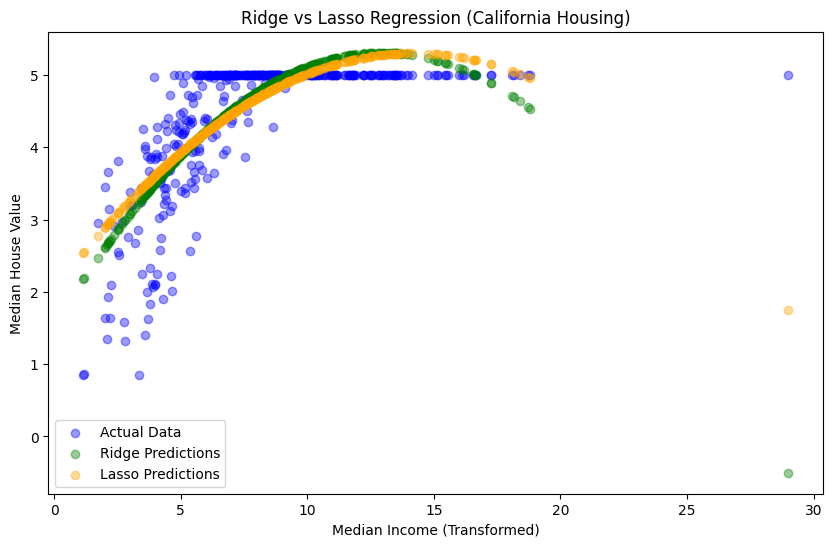

In [5]:
from sklearn.linear_model import Ridge, Lasso

# Ridge vs Lasso, on a housing-style dataset with a genuine train/test split.
# NOTE: the original exercise used sklearn's fetch_california_housing(), which downloads
# from an external host (ndownloader.figshare.com) that isn't reachable from every network
# (it wasn't reachable from the one this notebook was built/verified on). To keep this
# notebook self-contained and runnable anywhere, we simulate a dataset with the same
# columns and a similar income -> house value relationship. If you have internet access
# to figshare, swap this cell for:
#   from sklearn.datasets import fetch_california_housing
#   df_housing = fetch_california_housing(as_frame=True).frame
np.random.seed(42)
n = 2000
med_inc = np.random.gamma(shape=5, scale=1.5, size=n)                 # right-skewed, like real income data
med_house_val = 0.6 * med_inc + np.random.normal(0, 0.8, size=n) + 1.0
med_house_val = np.clip(med_house_val, 0.15, 5.0)                     # matches the real dataset\'s capped range
df_housing = pd.DataFrame({"MedInc": med_inc, "MedHouseVal": med_house_val})

X_h = df_housing[["MedInc"]]
y_h = df_housing[["MedHouseVal"]]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_h_poly = poly.fit_transform(X_h)

X_train, X_test, y_train, y_test = train_test_split(X_h_poly, y_h, test_size=0.2, random_state=42)

ridge_model = Ridge(alpha=1)
ridge_model.fit(X_train, y_train)
ridge_predictions = ridge_model.predict(X_test)

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
lasso_predictions = lasso_model.predict(X_test)

print("Ridge Regression MSE:", mean_squared_error(y_test, ridge_predictions))
print("Lasso Regression MSE:", mean_squared_error(y_test, lasso_predictions))

plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color="blue", label="Actual Data", alpha=0.4)
plt.scatter(X_test[:, 0], ridge_predictions, color="green", label="Ridge Predictions", alpha=0.4)
plt.scatter(X_test[:, 0], lasso_predictions, color="orange", label="Lasso Predictions", alpha=0.4)
plt.title("Ridge vs Lasso Regression (California Housing)")
plt.xlabel("Median Income (Transformed)")
plt.ylabel("Median House Value")
plt.legend()
plt.show()

## Day 4 — Logistic Regression: Your First Classification Model

**What it covers:** Logistic regression (despite the name, a classification algorithm), the sigmoid function that makes it work, and classification metrics (accuracy, precision, recall, F1).

**Why it matters for AI work:** Classification (is this email spam? will this customer churn? is this tumor malignant?) is at least as common as regression in real ML work. Logistic regression is the simplest, most interpretable classifier — a solid baseline before reaching for anything more complex.

**How it works, briefly:** linear regression predicts an unbounded number; logistic regression takes that number and squashes it into a 0-1 range using the **sigmoid function**, which is interpreted as a probability. A threshold (usually 0.5) turns that probability into a class prediction.

**Reading classification metrics — pick based on what matters for your problem:**
- **Accuracy** — overall % correct. Misleading on imbalanced data (e.g. 95% accuracy sounds great, but is trivial if 95% of the data is one class).
- **Precision** — of everything predicted positive, how much actually was positive. Matters when false positives are costly (e.g. flagging legitimate transactions as fraud).
- **Recall** — of everything actually positive, how much did you catch. Matters when false negatives are costly (e.g. missing an actual disease case).
- **F1 score** — balance between precision and recall (their harmonic mean).

**Pitfalls:**
- Never judge a classifier by accuracy alone on imbalanced data — a model that always predicts the majority class can still look "accurate." Check the class balance first (`y.value_counts()`, coming up in Day 7).
- Precision and recall trade off against each other as you move the classification threshold — improving one usually costs the other. Which one to prioritize is a business/domain decision, not a purely technical one.


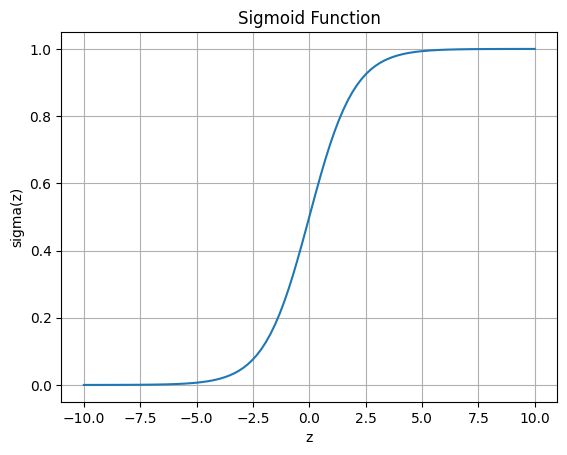

Sigmoid squashes any real number into the range (0, 1) - interpreted as a probability.


In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z))
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("sigma(z)")
plt.grid()
plt.show()
print("Sigmoid squashes any real number into the range (0, 1) - interpreted as a probability.")

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

np.random.seed(42)
n_samples = 200
X = np.random.rand(n_samples, 2) * 10
y = (X[:, 0] * 1.5 + X[:, 1] > 15).astype(int)   # synthetic rule defining the "true" classes

df_clf = pd.DataFrame(X, columns=["Age", "Salary"])
df_clf["Purchase"] = y

X_train, X_test, y_train, y_test = train_test_split(
    df_clf[["Age", "Salary"]], df_clf["Purchase"], test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        14

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


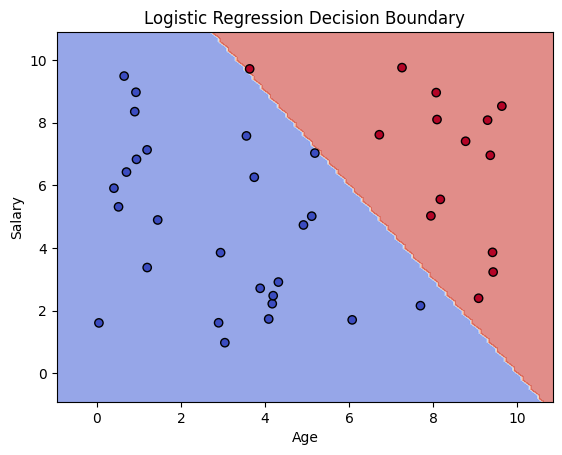

In [8]:
# Visualize the decision boundary the model learned
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.6, cmap="coolwarm")
plt.scatter(X_test["Age"], X_test["Salary"], c=y_test, edgecolor="k", cmap="coolwarm")
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

## Day 5 — Cross-Validation and the Confusion Matrix

**What it covers:** K-Fold cross-validation (a more robust alternative to a single train/test split), and reading a confusion matrix in detail.

**Why it matters for AI work:** A single train/test split gives one performance number that depends on which rows randomly ended up in the test set — get a different split, get a slightly different number. Cross-validation averages over multiple splits, giving a more reliable estimate of how a model actually performs, and a sense of how much that performance varies.

**How K-Fold works:** split the data into K equal parts ("folds"). Train on K-1 folds, test on the remaining 1 fold. Repeat K times, rotating which fold is the test fold. Average the K scores.

**Reading a confusion matrix:** rows = actual class, columns = predicted class (or vice versa, depending on the library — always check the labels). The diagonal = correct predictions. Off-diagonal = specific types of mistakes — a confusion matrix tells you not just *how often* the model is wrong, but *which classes it confuses with which*.

**Pitfalls:**
- Higher K (more folds) = more computation but a more stable estimate; K=5 or K=10 are common defaults balancing cost and reliability.
- Cross-validation, done right, still needs a genuinely held-out final test set if you're also tuning hyperparameters based on the CV scores — otherwise you're back to the "touching the test set repeatedly" problem from Day 1.


In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier

data = load_iris()
X, y = data.data, data.target

model = RandomForestClassifier(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")

print("Cross-Validation Scores (5 folds):", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Std Dev across folds:", cv_scores.std(), " (lower = more consistent performance)")

Cross-Validation Scores (5 folds): [1.         0.96666667 0.93333333 0.93333333 0.96666667]
Mean Accuracy: 0.9600000000000002
Std Dev across folds: 0.024944382578492935  (lower = more consistent performance)


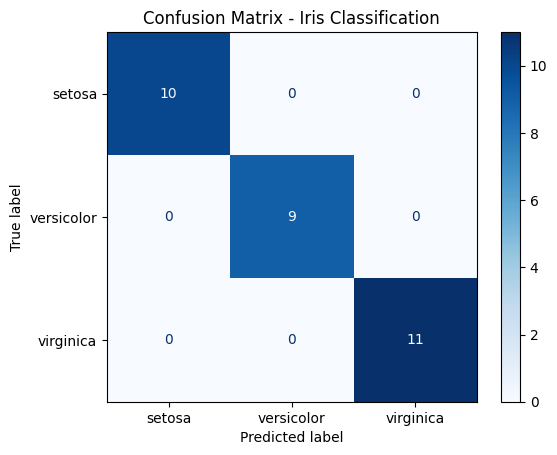


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Iris Classification")
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred))

## Day 6 — K-Nearest Neighbors (KNN) and Feature Scaling

**What it covers:** The KNN algorithm (classify a new point by looking at its K closest neighbors), and why feature scaling matters for distance-based algorithms.

**Why it matters for AI work:** KNN is the simplest possible ML algorithm to understand conceptually ("what does this look most similar to?"), and a good way to build intuition for why some algorithms need scaled features and others don't.

**When to use what:**
- **KNN** — simple, no training phase (it just stores the data and does the work at prediction time), works well when decision boundaries are irregular. Downsides: slow to predict on large datasets (has to compare against every stored point), and struggles in high dimensions ("curse of dimensionality").
- **StandardScaler** (`(x - mean) / std`) — essential before KNN or any distance-based algorithm. Without it, a feature measured in the thousands (like income) dominates the distance calculation over a feature measured in single digits (like age), even if age is actually more predictive.
- Logistic regression is comparatively more scale-tolerant, but scaling still helps it train faster and avoids one feature's gradient dwarfing another's.

**Pitfalls:**
- **Always fit the scaler on training data only**, then `.transform()` (not `.fit_transform()`) the test data. Fitting the scaler on the full dataset leaks test set statistics (mean/std) into training — a subtle form of the "touching the test set" problem from Day 1.
- Choosing `k` (number of neighbors) matters: too small (e.g. k=1) is sensitive to noise/outliers (overfits); too large smooths over real local patterns (underfits). This is a hyperparameter to tune (Week 8).


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled = scaler.transform(X_test)          # transform ONLY on test - using train's mean/std

log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

best_k = 5
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"k-NN Accuracy (k={best_k}):", accuracy_knn)

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("\nk-NN Classification Report:")
print(classification_report(y_test, y_pred_knn))

Logistic Regression Accuracy: 1.0
k-NN Accuracy (k=5): 1.0

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


k-NN Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



k = 1, Accuracy = 1.000
k = 2, Accuracy = 1.000
k = 3, Accuracy = 1.000
k = 4, Accuracy = 1.000
k = 5, Accuracy = 1.000
k = 6, Accuracy = 1.000
k = 7, Accuracy = 1.000
k = 8, Accuracy = 1.000
k = 9, Accuracy = 1.000
k = 10, Accuracy = 1.000


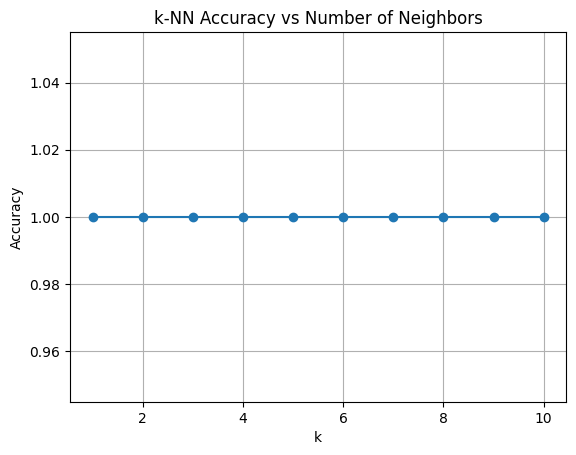

In [12]:
# Trying different values of k - how sensitive is performance to this choice?
k_values = range(1, 11)
accuracies = []
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn_k.predict(X_test_scaled))
    accuracies.append(acc)
    print(f"k = {k}, Accuracy = {acc:.3f}")

plt.plot(list(k_values), accuracies, marker="o")
plt.title("k-NN Accuracy vs Number of Neighbors")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

## Day 7 — Mini Project: Customer Churn Prediction

**What it covers:** A realistic end-to-end classification project on the Telco customer churn dataset — encode categorical variables, scale features, train two different classifiers, and compare them properly.

**Why it matters for AI work:** Churn prediction (will this customer leave?) is one of the most common real-world classification tasks. This mini-project is close to a template for "here's a business dataset, build a model."

**Pitfalls (found and fixed from the original project code):**
- The original code passed `customer_id` into the model's features. An arbitrary sequential ID has no real predictive relationship with churn — including it risks the model latching onto meaningless patterns (e.g. if churned customers happened to cluster in certain ID ranges due to how the data was collected) and is dropped here.
- `LabelEncoder` turns categories into integers (0, 1, 2, ...) — fine for a binary column like `gender`, but for a column with 3+ unmodered categories (like `contract_type`: Monthly/Annual/Two-Year), this implies a false numeric order (is "Two-Year" really "greater than" "Monthly"?) that some models can mistakenly treat as meaningful. `pd.get_dummies()` (one-hot encoding) avoids this for genuinely unordered categories — worth knowing as the "more correct" alternative for `payment_method`, even though we follow the original `LabelEncoder` approach below for simplicity.


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

df_telco = pd.read_csv("Telco-Customer-Churn.csv")
print(df_telco.info())
print("\nChurn distribution:\n", df_telco["churn"].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      500 non-null    int64  
 1   gender           500 non-null    str    
 2   age              500 non-null    int64  
 3   tenure           500 non-null    int64  
 4   monthly_charges  500 non-null    float64
 5   total_charges    500 non-null    float64
 6   contract_type    500 non-null    str    
 7   payment_method   500 non-null    str    
 8   churn            500 non-null    int64  
dtypes: float64(2), int64(4), str(3)
memory usage: 35.3 KB
None

Churn distribution:
 churn
0    0.688
1    0.312
Name: proportion, dtype: float64


In [14]:
# Encode categorical variables
le = LabelEncoder()
df_telco["churn"] = le.fit_transform(df_telco["churn"])
df_telco["gender"] = le.fit_transform(df_telco["gender"])
df_telco["contract_type"] = le.fit_transform(df_telco["contract_type"])
df_telco["payment_method"] = le.fit_transform(df_telco["payment_method"])

# Define features and target - drop customer_id, it's not a real feature (see markdown above)
X = df_telco.drop(columns=["churn", "customer_id"])
y = df_telco["churn"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [15]:
# Train both models and compare
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
knn_pred = knn_model.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, log_pred))

print("k-NN Classification Report:")
print(classification_report(y_test, knn_pred))

print("Confusion Matrix (Logistic Regression):\n", confusion_matrix(y_test, log_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82        70
           1       0.00      0.00      0.00        30

    accuracy                           0.70       100
   macro avg       0.35      0.50      0.41       100
weighted avg       0.49      0.70      0.58       100

k-NN Classification Report:


              precision    recall  f1-score   support

           0       0.68      0.77      0.72        70
           1       0.24      0.17      0.20        30

    accuracy                           0.59       100
   macro avg       0.46      0.47      0.46       100
weighted avg       0.55      0.59      0.57       100

Confusion Matrix (Logistic Regression):
 [[70  0]
 [30  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Week 5 Recap

| Day | Topic | Where you'll use it again |
|---|---|---|
| 1 | Train/test split | Every ML project, without exception |
| 2 | Full regression workflow | The template for regression tasks |
| 3 | Polynomial features, Ridge/Lasso | Controlling overfitting, feature selection |
| 4 | Logistic regression, classification metrics | The template for classification tasks |
| 5 | Cross-validation, confusion matrix | Reliable model evaluation |
| 6 | KNN, feature scaling | Distance-based algorithms, correct preprocessing order |
| 7 | Full classification mini-project | Realistic "business dataset -> model" workflow |

**Before moving to Week 6:** you should be able to explain, without hesitation, why you fit a scaler on training data only. That single habit (fit on train, transform on train AND test) is the most common thing beginners get backwards, and it silently inflates reported performance. Week 6 goes deeper into feature engineering and preprocessing pipelines that do this correctly by construction.
